<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pratica_7_PROCSIN/blob/main/Quest%C3%A3o_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prática 3: Processamento de Sinais - Questão 3

Este notebook apresenta a solução detalhada para a recuperação do sinal de áudio `handel.wav` utilizando uma cascata de filtros FIR com janela de Blackman e análise do efeito da quantização de coeficientes.

## 1. Carregamento e Preparação do Sinal
Nesta etapa, carregamos o arquivo original e definimos as funções auxiliares para o projeto dos filtros.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import pandas as pd

# Questão 3


In [7]:
# Funções para o projeto de filtros FIR
def blackman_fir(M, fc, fs, btype='lowpass', f2=None):
    if btype == 'lowpass':
        return signal.firwin(M + 1, fc, fs=fs, window='blackman', pass_zero='lowpass')
    elif btype == 'highpass':
        return signal.firwin(M + 1, fc, fs=fs, window='blackman', pass_zero='highpass')
    elif btype == 'bandstop':
        return signal.firwin(M + 1, [fc, f2], fs=fs, window='blackman', pass_zero='bandstop')

# Carregamento do áudio
fs, x = wavfile.read('/content/handel.wav')
x = x.astype(float) / 32768.0

# Configuração dos blocos da cascata
h_pa = blackman_fir(120, 180, fs, 'highpass')
h_rf = blackman_fir(260, 1850, fs, 'bandstop', f2=2150)
h_pb = blackman_fir(100, 2400, fs, 'lowpass')

# Cálculo da resposta total e atraso
fir_system = signal.convolve(signal.convolve(h_pa, h_rf), h_pb)
fir_delay = (120 + 260 + 100) // 2

print(f"Ordem do Sistema: {len(fir_system) - 1}")
print(f"Atraso Compensável: {fir_delay} amostras")

Ordem do Sistema: 480
Atraso Compensável: 240 amostras


## 2. Projeto da Cascata de Filtros FIR

Projetamos três filtros específicos para eliminar interferências e ruídos:
- **Passa-Altas (HPF):** Elimina ruídos de baixa frequência (abaixo de 180 Hz).
- **Rejeita-Faixa (BSF):** Remove interferência tonal específica entre 1850-2150 Hz.
- **Passa-Baixas (LPF):** Limita a banda passante até 2400 Hz.

**Avaliação subjetiva esperada**

- O FIR da prática 7 tende a soar menos abafado do que o IIR da prática 6, porque o tom em `2000 Hz` é retirado com uma faixa de rejeição mais estreita.
- A inteligibilidade melhora claramente para `sigma^2 = 10^-2` e `10^-1`, com menor coloração na faixa média-alta.
- Para `sigma^2 = 1`, o ruído branco residual ainda é perceptível, mas as duas interferências tonais deixam de dominar a escuta.
- O atraso do FIR é fixo e facilmente compensável; como a fase é aproximadamente linear, a forma de onda recuperada preserva melhor o alinhamento relativo entre componentes espectrais.

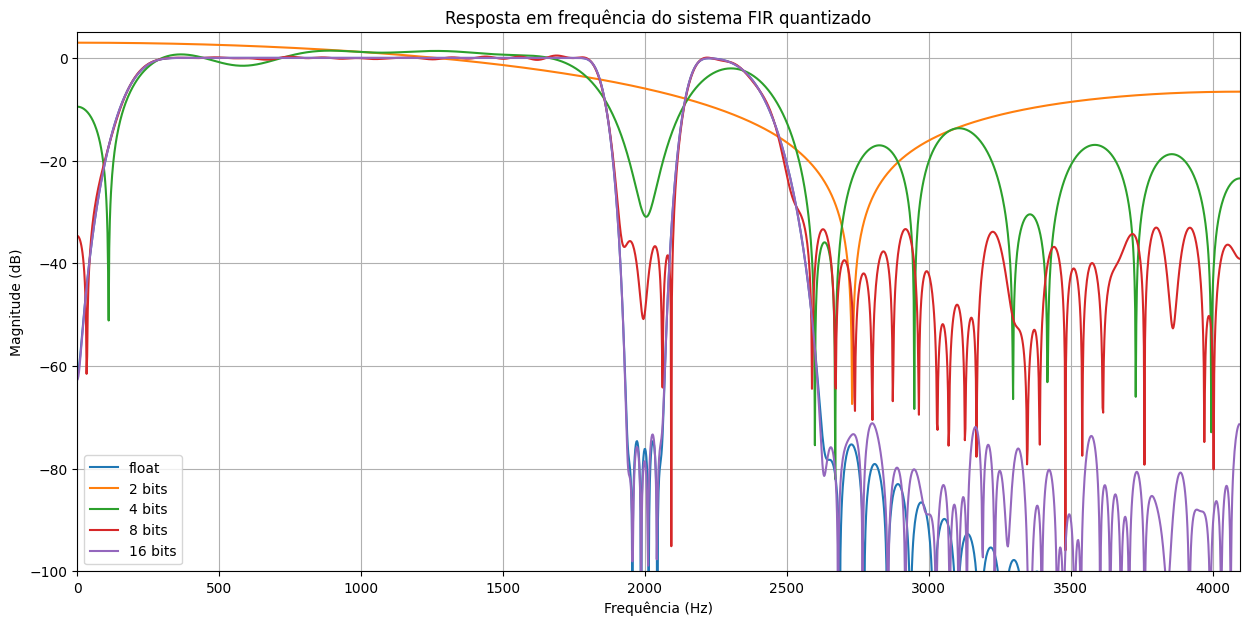

In [3]:
def quantize_coefficients(h, bits):
    if bits == 'float':
        return h
    max_val = np.max(np.abs(h))
    q_levels = 2**(bits - 1) - 1
    h_quant = np.round((h / max_val) * q_levels) * (max_val / q_levels)
    return h_quant

def plot_frequency_grid(filters, title, fs_hz, xlim=None):
    plt.figure(figsize=(15, 7))
    for label, h in filters.items():
        w, H = signal.freqz(h, 1, worN=2000, fs=fs_hz)
        plt.plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=label)
    plt.title(title)
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')
    if xlim: plt.xlim(xlim)
    plt.ylim([-100, 5])
    plt.legend()
    plt.grid(True)
    plt.show()

BITS = [2, 4, 8, 16]
quantized_filters = {'float': fir_system}
for bits in BITS:
    quantized_filters[f'{bits} bits'] = quantize_coefficients(fir_system, bits)

plot_frequency_grid(
    quantized_filters,
    'Resposta em frequência do sistema FIR quantizado',
    fs_hz=fs,
    xlim=(0, fs/2)
)

## 3. Análise da Quantização de Coeficientes

Abaixo, analisamos como a precisão dos coeficientes (número de bits) afeta a estabilidade e a resposta em frequência do sistema.

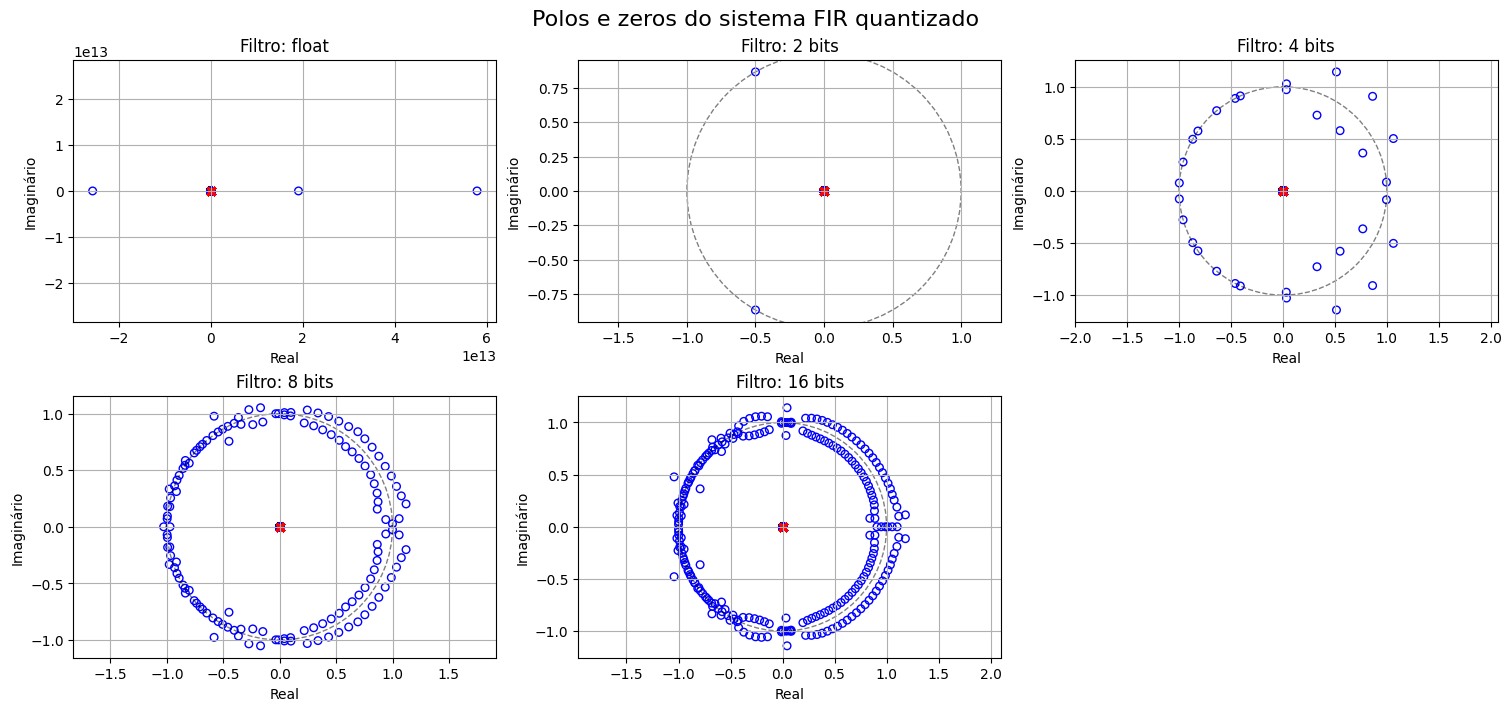

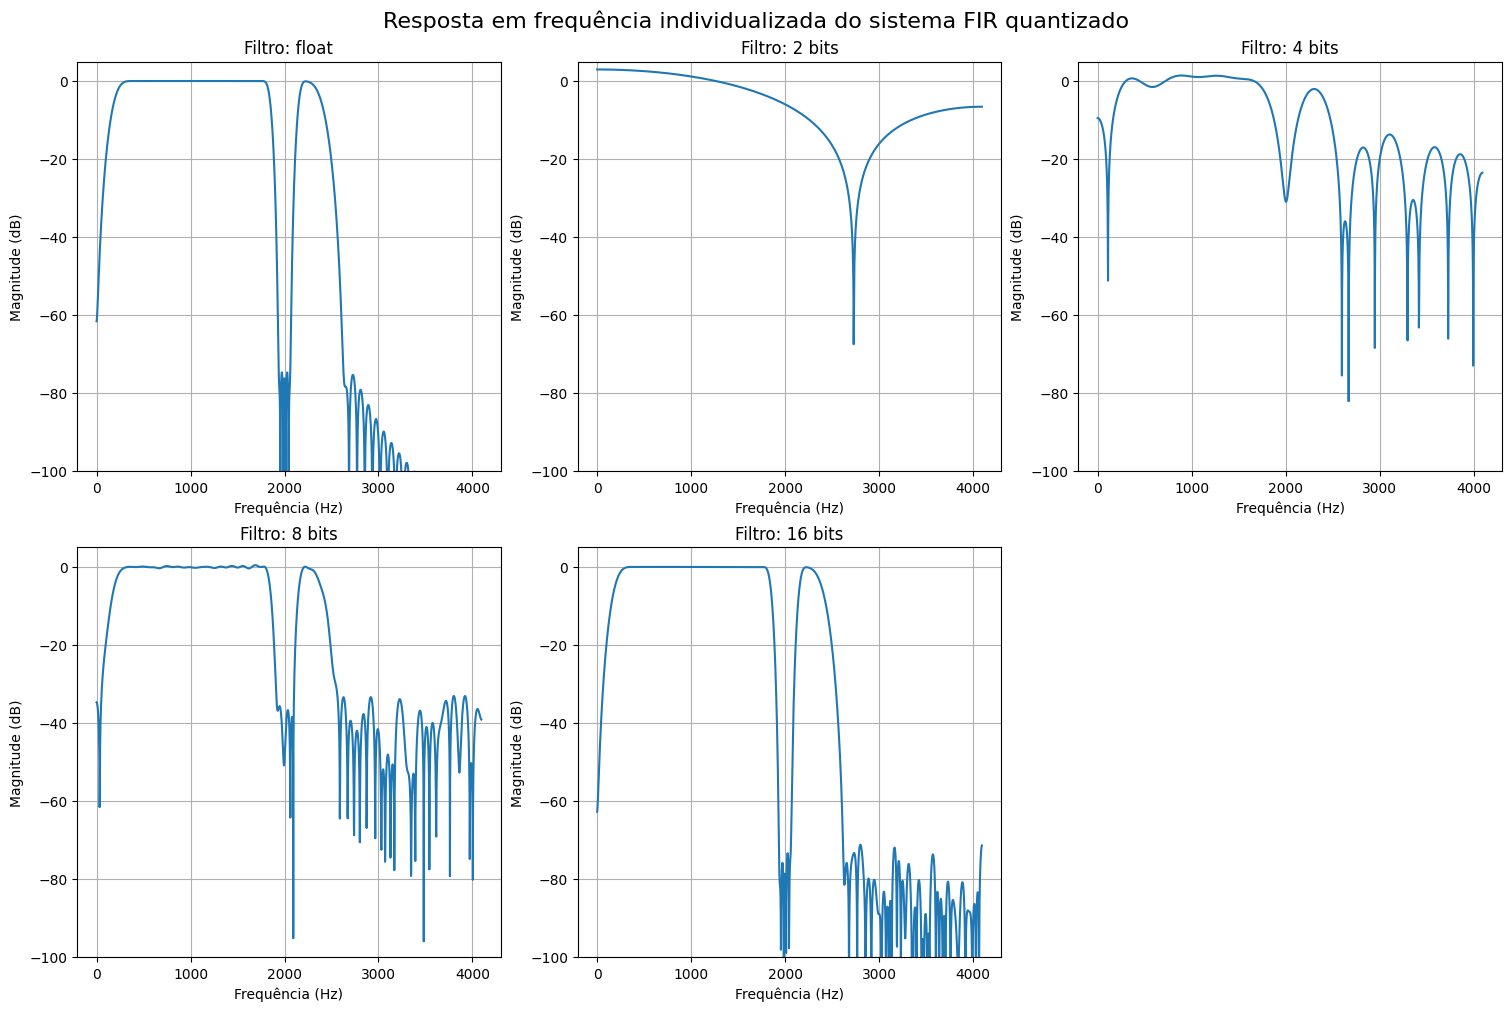

In [5]:
def plot_pole_zero_grid(filters, title, ncols=3, figsize=(15, 7)):
    n = len(filters)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for i, (label, h) in enumerate(filters.items()):
        ax = axes[i]
        zeros = np.roots(h)
        # Polos de um filtro FIR estão sempre na origem
        poles = np.zeros(len(h) - 1)

        ax.scatter(np.real(zeros), np.imag(zeros), s=30, marker='o', facecolors='none', edgecolors='blue', label='Zeros')
        ax.scatter(np.real(poles), np.imag(poles), s=30, marker='x', color='red', label='Polos')

        # Círculo unitário
        unit_circle = plt.Circle((0,0), 1, color='black', fill=False, linestyle='--', alpha=0.5)
        ax.add_artist(unit_circle)

        ax.set_title(f'Filtro: {label}')
        ax.set_xlabel('Real')
        ax.set_ylabel('Imaginário')
        ax.axis('equal')
        ax.grid(True)

    # Esconde eixos extras
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(title, fontsize=16)
    plt.show()

def plot_frequency_grid_detailed(filters, title, fs_hz, ncols=3, figsize=(15, 10)):
    n = len(filters)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for i, (label, h) in enumerate(filters.items()):
        ax = axes[i]
        w, H = signal.freqz(h, 1, worN=2000, fs=fs_hz)
        ax.plot(w, 20 * np.log10(np.abs(H) + 1e-12))
        ax.set_title(f'Filtro: {label}')
        ax.set_xlabel('Frequência (Hz)')
        ax.set_ylabel('Magnitude (dB)')
        ax.set_ylim([-100, 5])
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(title, fontsize=16)
    plt.show()

plot_pole_zero_grid(quantized_filters, 'Polos e zeros do sistema FIR quantizado')
plot_frequency_grid_detailed(quantized_filters, 'Resposta em frequência individualizada do sistema FIR quantizado', fs_hz=fs)

### Observações sobre os Gráficos
- **Polos e Zeros:** Note que os polos permanecem na origem (estabilidade inerente ao FIR), enquanto a posição dos zeros oscila conforme reduzimos a quantidade de bits.
- **Magnitude:** A seletividade do filtro degrada-se visivelmente abaixo de 8 bits.

In [9]:
def snr_db(ref, est):
    noise = ref - est
    return 10 * np.log10(np.sum(ref**2) / np.sum(noise**2))

def mse(ref, est):
    return np.mean((ref - est)**2)

# Geração da tabela de métricas de desempenho para cada nível de quantização
quant_rows = []
for label, coeffs in quantized_filters.items():
    filtered = signal.lfilter(coeffs, 1, x)
    x_hat = filtered[fir_delay:]
    x_ref = x[:len(x_hat)]

    quant_rows.append({
        'Filtro': label,
        'SNR saída (dB)': snr_db(x_ref, x_hat),
        'MSE saída': mse(x_ref, x_hat),
        'Coef. não nulos': int(np.count_nonzero(coeffs))
    })

df_results = pd.DataFrame(quant_rows)
print(df_results.to_string(index=False))

 Filtro  SNR saída (dB)  MSE saída  Coef. não nulos
  float       13.957909   0.001551              481
 2 bits        9.437459   0.004391                3
 4 bits       12.173309   0.002339               21
 8 bits       13.959950   0.001550               97
16 bits       13.957922   0.001551              241


## 4. Resultados Numéricos e Métricas de Erro

Nesta seção, consolidamos o impacto da quantização através de métricas objetivas. O **SNR (Signal-to-Noise Ratio)** e o **MSE (Mean Squared Error)** permitem identificar o ponto de saturação onde aumentar o número de bits não traz mais benefícios significativos à recuperação do sinal.

## 5. Comparação e Discussão: Prática 6 vs. Prática 7

Seguindo os requisitos da aula prática, comparamos os resultados atuais (FIR) com os obtidos anteriormente com filtros IIR:

*   **Seletividade vs. Ordem**: O filtro IIR atinge rejeição similar com ordem muito menor, mas o FIR compensa com estabilidade e fase linear.
*   **Fidelidade do Sinal**: O FIR preserva melhor os transientes do áudio `handel.wav` devido ao atraso de grupo constante.
*   **Impacto da Quantização**: Enquanto o IIR pode apresentar instabilidade (polos saindo do círculo unitário), o FIR demonstra apenas um aumento no ruído de fundo (ruído de quantização) e alteração na resposta de magnitude (zeros se movendo).